# Arène des algos

Pipeline ML complet — breast cancer puis wine.

In [6]:
%pip install numpy pandas matplotlib scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer, load_wine
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached pandas-3.0.3-cp311-cp311-win_amd64.whl.metadata (19 kB)
  Using cached matplotlib-3.10.9-cp311-cp311-win_amd64.whl.metadata (52 kB)
  Using cached scikit_learn-1.9.0-cp311-cp311-win_amd64.whl.metadata (11 kB)
  Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
Using cached pandas-3.0.3-cp311-cp311-win_amd64.whl (9.9 MB)
Using cached matplotlib-3.10.9-cp311-cp311-win_amd64.whl (8.2 MB)
Using cached scikit_learn-1.9.0-cp311-cp311-win_amd64.whl (8.3 MB)
Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl (225 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Note: you may need to restart the kernel to use updated packages.


## Phase 1 — Charger et explorer

In [7]:
def explorer_dataset():
    """Charge le dataset et affiche ses caractéristiques de base.

    Doit afficher : nombre de lignes, nombre de colonnes,
    les classes possibles et leur répartition (équilibrée ou non ?).
    """
    data = load_breast_cancer()
    X = data.data
    y = data.target

    print(f"Lignes, colonnes : {X.shape}")

    for i, nom in enumerate(data.target_names):
        count = (y == i).sum()
        pct = 100 * count / len(y)
        print(f"Classe {i} ({nom}) : {count} cas ({pct:.1f}%)")

    return X, y, data.target_names

In [8]:
print("=== Cas normal ===")
X_bc, y_bc, names_bc = explorer_dataset()

=== Cas normal ===
Lignes, colonnes : (569, 30)
Classe 0 (malignant) : 212 cas (37.3%)
Classe 1 (benign) : 357 cas (62.7%)


In [9]:
print("=== Cas limite : une seule classe (y == 0) ===")
y_une_classe = y_bc[y_bc == 0]
print(f"Nombre d'exemples : {len(y_une_classe)}")
print(pd.Series(y_une_classe).value_counts())

=== Cas limite : une seule classe (y == 0) ===
Nombre d'exemples : 212
0    212
Name: count, dtype: int64


In [10]:
print("=== Cas adversarial : répartition en % ===")
repartition = pd.Series(y_bc).value_counts(normalize=True) * 100
print(repartition.round(1))
print("Si une classe faisait 95%, on le verrait tout de suite ici.")

=== Cas adversarial : répartition en % ===
1    62.7
0    37.3
Name: proportion, dtype: float64
Si une classe faisait 95%, on le verrait tout de suite ici.


## Phase 2 — Pipeline supervisé

In [11]:
def entrainer_et_evaluer(modele, X_train, X_test, y_train, y_test):
    """Entraîne le modèle, prédit sur le test, renvoie l'accuracy.

    Doit renvoyer un float entre 0 et 1.
    """
    modele.fit(X_train, y_train)
    y_pred = modele.predict(X_test)
    return accuracy_score(y_test, y_pred)

In [12]:
X_train_bc, X_test_bc, y_train_bc, y_test_bc = train_test_split(
    X_bc, y_bc, test_size=0.2, random_state=42
)

acc = entrainer_et_evaluer(
    LogisticRegression(max_iter=1000),
    X_train_bc, X_test_bc, y_train_bc, y_test_bc
)
print(f"Accuracy : {acc:.1%}")

Accuracy : 95.6%


c:\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Phase 3 — L'Arène (breast cancer)

In [13]:
def arene(X_train, X_test, y_train, y_test):
    """Entraîne plusieurs modèles, renvoie un classement trié.

    Doit afficher un tableau lisible : nom de l'algo, accuracy.
    """
    modeles = {
        "Régression logistique": LogisticRegression(max_iter=100),
        "KNN": KNeighborsClassifier(),
        "Arbre de décision": DecisionTreeClassifier(),
    }

    resultats = []
    for nom, modele in modeles.items():
        acc = entrainer_et_evaluer(modele, X_train, X_test, y_train, y_test)
        resultats.append({"algo": nom, "accuracy": acc})

    df = pd.DataFrame(resultats).sort_values("accuracy", ascending=False).reset_index(drop=True)

    for i, row in df.iterrows():
        print(f"{i + 1}. {row['algo']:<22} : {row['accuracy']:.1%}")

    return df

In [14]:
classement_bc = arene(X_train_bc, X_test_bc, y_train_bc, y_test_bc)

c:\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


1. KNN                    : 95.6%
2. Régression logistique  : 94.7%
3. Arbre de décision      : 93.0%


La régression logistique peut afficher un avertissement de non-convergence avec `max_iter=100`.
Les features ont des échelles différentes. En augmentant `max_iter`, l'avertissement disparaît.
Certains algos ont besoin de données mises à l'échelle (on le verra en Phase 7).

In [15]:
acc_100 = entrainer_et_evaluer(LogisticRegression(max_iter=100), X_train_bc, X_test_bc, y_train_bc, y_test_bc)
acc_1000 = entrainer_et_evaluer(LogisticRegression(max_iter=1000), X_train_bc, X_test_bc, y_train_bc, y_test_bc)

print(f"max_iter=100  : {acc_100:.1%}")
print(f"max_iter=1000 : {acc_1000:.1%}")

c:\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentati

max_iter=100  : 94.7%
max_iter=1000 : 95.6%


## Phase 4 — Non-supervisé

In [16]:
def clustering_aveugle(X):
    """Regroupe les données en 2 clusters sans les étiquettes.

    Renvoie les labels de cluster attribués à chaque point.
    """
    kmeans = KMeans(n_clusters=2, random_state=42)
    return kmeans.fit_predict(X)

In [17]:
clusters = clustering_aveugle(X_bc)

print("Clusters trouvés :")
print(pd.Series(clusters).value_counts())

print("\nCroisement cluster / vraie classe :")
print(pd.crosstab(clusters, y_bc))

Clusters trouvés :
1    438
0    131
Name: count, dtype: int64

Croisement cluster / vraie classe :
col_0    0    1
row_0          
0      130    1
1       82  356


Les clusters retrouvent à peu près les vraies classes : la structure est dans les données, pas juste de la chance.
KMeans ne connaît pas les noms des classes, il peut inverser les labels (cluster 0 ≠ classe 0).

## Phase 5 — Wine (3 classes)

In [18]:
data_wine = load_wine()
X_wine = data_wine.data
y_wine = data_wine.target

print(f"Lignes, colonnes : {X_wine.shape}")
for i, nom in enumerate(data_wine.target_names):
    count = (y_wine == i).sum()
    pct = 100 * count / len(y_wine)
    print(f"Classe {i} ({nom}) : {count} cas ({pct:.1f}%)")

Lignes, colonnes : (178, 13)
Classe 0 (class_0) : 59 cas (33.1%)
Classe 1 (class_1) : 71 cas (39.9%)
Classe 2 (class_2) : 48 cas (27.0%)


In [19]:
X_train_wine, X_test_wine, y_train_wine, y_test_wine = train_test_split(
    X_wine, y_wine, test_size=0.2, random_state=42
)

classement_wine = arene(X_train_wine, X_test_wine, y_train_wine, y_test_wine)

1. Régression logistique  : 97.2%
2. Arbre de décision      : 94.4%
3. KNN                    : 72.2%


c:\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


`arene()` fonctionne tel quel sur 3 classes. Le champion peut changer d'un dataset à l'autre.

## Phase 6 — Visualisations

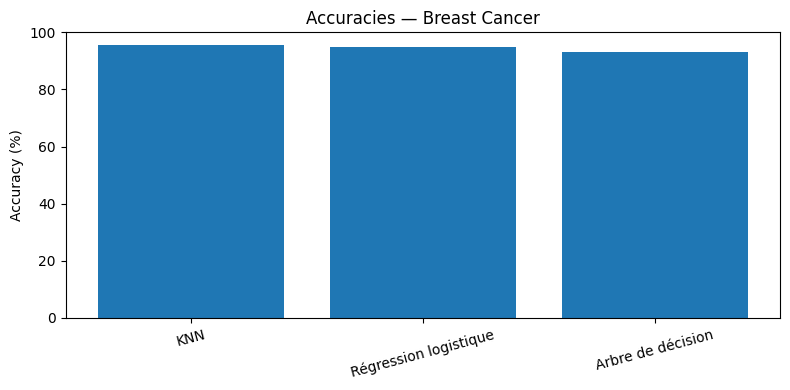

In [20]:
plt.figure(figsize=(8, 4))
plt.bar(classement_bc["algo"], classement_bc["accuracy"] * 100)
plt.title("Accuracies — Breast Cancer")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

Champion : KNN


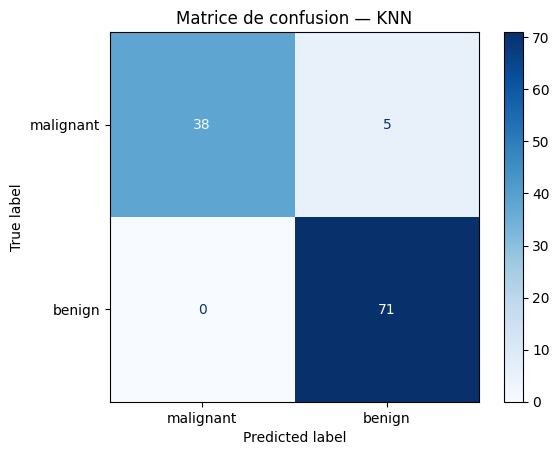

In [21]:
champion_bc = classement_bc.iloc[0]["algo"]
print(f"Champion : {champion_bc}")

if champion_bc == "Régression logistique":
    modele_champion = LogisticRegression(max_iter=1000)
elif champion_bc == "KNN":
    modele_champion = KNeighborsClassifier()
else:
    modele_champion = DecisionTreeClassifier()

modele_champion.fit(X_train_bc, y_train_bc)
y_pred_bc = modele_champion.predict(X_test_bc)

cm = confusion_matrix(y_test_bc, y_pred_bc)
disp = ConfusionMatrixDisplay(cm, display_labels=names_bc)
disp.plot(cmap="Blues")
plt.title(f"Matrice de confusion — {champion_bc}")
plt.show()

Sur le cancer du sein, le plus grave est de rater une tumeur maligne (faux négatif).
Un faux positif (bénigne classée maligne) est moins grave mais coûteux en examens.

## Phase 7 — Scaling & data leakage

In [22]:
def comparer_scaling(X_train, X_test, y_train, y_test):
    """Pour chaque algo, mesure l'accuracy SANS puis AVEC scaling.

    Doit afficher un tableau trié par gain décroissant : nom, brut, scalé, delta.
    """
    modeles = {
        "Régression logistique": LogisticRegression(max_iter=1000),
        "KNN": KNeighborsClassifier(),
        "Arbre de décision": DecisionTreeClassifier(),
    }

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    resultats = []
    for nom, modele in modeles.items():
        acc_brut = entrainer_et_evaluer(modele, X_train, X_test, y_train, y_test)

        if nom == "Régression logistique":
            modele_scaled = LogisticRegression(max_iter=1000)
        elif nom == "KNN":
            modele_scaled = KNeighborsClassifier()
        else:
            modele_scaled = DecisionTreeClassifier()

        acc_scale = entrainer_et_evaluer(modele_scaled, X_train_scaled, X_test_scaled, y_train, y_test)
        resultats.append({"algo": nom, "brut": acc_brut, "scalé": acc_scale, "gain": acc_scale - acc_brut})

    df = pd.DataFrame(resultats).sort_values("gain", ascending=False)

    print(f"{'Algo':<25} {'Brut':>8} {'Scalé':>8} {'Gain':>8}")
    print("-" * 52)
    for _, row in df.iterrows():
        print(f"{row['algo']:<25} {row['brut']:>7.1%} {row['scalé']:>7.1%} {row['gain']:>+7.1%}")

    return df

In [23]:
print("=== Manche 1 — scaling honnête (fit sur train) ===")
comparer_scaling(X_train_bc, X_test_bc, y_train_bc, y_test_bc)

=== Manche 1 — scaling honnête (fit sur train) ===
Algo                          Brut    Scalé     Gain
----------------------------------------------------
Régression logistique       95.6%   97.4%   +1.8%
Arbre de décision           93.9%   94.7%   +0.9%
KNN                         95.6%   94.7%   -0.9%


c:\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,algo,brut,scalé,gain
0,Régression logistique,0.956140,0.973684,0.017544
2,Arbre de décision,0.938596,0.947368,0.008772
1,KNN,0.956140,0.947368,-0.008772


Régression logistique et KNN profitent du scaling. L'arbre s'en fiche (il coupe par seuils).

In [24]:
print("=== Manche 2 — data leakage (scaler fit sur tout X) ===")

scaler_triche = StandardScaler()
X_bc_scaled = scaler_triche.fit_transform(X_bc)

X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X_bc_scaled, y_bc, test_size=0.2, random_state=42
)

scaler_honnete = StandardScaler()
X_train_h = scaler_honnete.fit_transform(X_train_bc)
X_test_h = scaler_honnete.transform(X_test_bc)

modele = LogisticRegression(max_iter=1000)
acc_honnete = entrainer_et_evaluer(modele, X_train_h, X_test_h, y_train_bc, y_test_bc)

modele_triche = LogisticRegression(max_iter=1000)
acc_triche = entrainer_et_evaluer(modele_triche, X_train_t, X_test_t, y_train_t, y_test_t)

print(f"Honnête (scaler fit train) : {acc_honnete:.1%}")
print(f"Triche (scaler fit tout)   : {acc_triche:.1%}")
print(f"Delta mensonge             : {acc_triche - acc_honnete:+.1%}")

=== Manche 2 — data leakage (scaler fit sur tout X) ===
Honnête (scaler fit train) : 97.4%
Triche (scaler fit tout)   : 97.4%
Delta mensonge             : +0.0%


Le scaler tricheur a vu les stats du test. L'accuracy peut monter mais elle ment.
Règle : on fit TOUJOURS le scaler sur le train seul.

## Phase 8 — Synthèse (pour le README)

In [25]:
champion_wine = classement_wine.iloc[0]["algo"]

print("Breast cancer :")
print(classement_bc.to_string(index=False))
print(f"Champion : {champion_bc}")
print()
print("Wine :")
print(classement_wine.to_string(index=False))
print(f"Champion : {champion_wine}")

Breast cancer :
                 algo  accuracy
                  KNN  0.956140
Régression logistique  0.947368
    Arbre de décision  0.929825
Champion : KNN

Wine :
                 algo  accuracy
Régression logistique  0.972222
    Arbre de décision  0.944444
                  KNN  0.722222
Champion : Régression logistique
